# Author:: \<Mohammad_Amin_Kiani\>
# ID::     \<4043644008\>

### Exercise 2 – Embeddings for Text Classification
================================================

##### Part 1.1
--------
Sentiment analysis on NLTK movie_reviews using Word2Vec embeddings
and two classifiers:
  - Logistic Regression
  - K-NN with cosine distance

It compares vector_size values: 50, 100, 200.

##### Part 1.2
--------
BBC News multi-class classification using pre-trained GloVe embeddings
and two classifiers:
  - Logistic Regression (OvR)
  - Linear SVM

It also reports OOV coverage for the BBC corpus and compares
GloVe dimensionalities with multiple files(e.g. 50d, 100d, 200d).

##### Requirements
------------
numpy scikit-learn gensim nltk



### STPs

In [1]:
%pip install numpy pandas nltk gensim scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Almahdi\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip


ما در کل تمرین نیازی به سی بورن نداریم.

می‌توانیم فقط از متپلات لیب استفاده کنیم.

In [2]:
import nltk
nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Almahdi\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


True

In [3]:
# =========================================================
# Imports
# =========================================================

from __future__ import annotations

import os
import re
import sys
from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

from gensim.models import Word2Vec, KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

import nltk


### Part 1.1 – NLTK movie_reviews + Word2Vec

In [4]:
# Part 1.1 word2vec dimensions to test
WORD2VEC_DIMS = [50, 100, 200]

# Common word2vec params required by the assignment
W2V_WINDOW = 5
W2V_MIN_COUNT = 2

# Simple text cleaning: keep alphabetic tokens only
TOKEN_RE = re.compile(r"[a-z]+")

RANDOM_STATE = 42

# X_train, X_test, y_train, y_test = train_test_split(
#     docs,
#     labels,
#     test_size=0.2,
#     stratify=labels,
#     random_state=42
# )
#
# model = Word2Vec(
#     sentences=X_train,
#     vector_size=100,
#     window=5,
#     min_count=2,
#     workers=4
# )
#

# #-----------------------------------------------------
# # Logistic Regression
# lr = LogisticRegression(max_iter=3000)
#
# lr.fit(Xtrain_vec,y_train)
#
# pred = lr.predict(Xtest_vec)
#
# #-----------------------------------------------------
# # KNN
# knn = KNeighborsClassifier(
#     n_neighbors=1,
#     metric="cosine"
# )
#
# #-----------------------------------------------------
# # Accuracy
# print(accuracy_score(y_test,pred))
#
# # Confusion Matrix
# cm = confusion_matrix(y_test,pred)
#
# sns.heatmap(cm,annot=True)
# plt.show()


In [5]:
# ============================================================
# Helpers
# ============================================================

def resolve_existing_path(candidates: Sequence[Path]) -> Path:
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "None of the expected paths exist:\n" + "\n".join(str(p) for p in candidates)
    )


def ensure_nltk_resource(resource: str) -> None:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource.split("/")[-1], quiet=True)


def preprocess_text(text: str) -> List[str]:
    """
    Lowercase and keep alphabetic tokens only.
    This is intentionally simple and deterministic.
    """
    tokens = TOKEN_RE.findall(text.lower())
    return tokens


def mean_vector(tokens: Sequence[str], keyed_vectors: KeyedVectors) -> np.ndarray:
    """
    Average in-vocabulary vectors for a document.

    OOV handling:
    - ignore OOV tokens
    - if no token is in vocab, return an all-zero vector
    """
    vecs = []
    for tok in tokens:
        if tok in keyed_vectors:
            vecs.append(keyed_vectors[tok])
    if not vecs:
        return np.zeros(keyed_vectors.vector_size, dtype=np.float32)
    return np.mean(np.asarray(vecs, dtype=np.float32), axis=0)


def texts_to_matrix(texts: Sequence[Sequence[str]], keyed_vectors: KeyedVectors) -> np.ndarray:
    return np.vstack([mean_vector(doc, keyed_vectors) for doc in texts])


def oov_coverage(texts: Sequence[Sequence[str]], keyed_vectors: KeyedVectors) -> Dict[str, float]:
    """
    Returns token-level and type-level OOV percentages.
    """
    total_tokens = 0
    oov_tokens = 0
    types = set()
    oov_types = set()

    for doc in texts:
        for tok in doc:
            types.add(tok)
            total_tokens += 1
            if tok not in keyed_vectors:
                oov_tokens += 1
                oov_types.add(tok)

    type_total = len(types)
    return {
        "token_oov_pct": 100.0 * oov_tokens / max(total_tokens, 1),
        "token_coverage_pct": 100.0 * (total_tokens - oov_tokens) / max(total_tokens, 1),
        "type_oov_pct": 100.0 * len(oov_types) / max(type_total, 1),
        "type_coverage_pct": 100.0 * (type_total - len(oov_types)) / max(type_total, 1),
        "total_tokens": float(total_tokens),
        "total_types": float(type_total),
    }


def print_eval(name: str, y_true: np.ndarray, y_pred: np.ndarray, labels: Sequence[str] | None = None) -> Dict[str, float]:
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    if labels is not None:
        print("Classification Report:")
        print(classification_report(y_true, y_pred, target_names=labels))
    return {"accuracy": acc, "macro_f1": macro_f1}

In [6]:
# ============================================================
# Part 1.1 – NLTK movie_reviews + Word2Vec
# ============================================================

def load_movie_reviews() -> Tuple[List[List[str]], np.ndarray]:
    ensure_nltk_resource("corpora/movie_reviews")
    from nltk.corpus import movie_reviews

    docs = []
    labels = []

    for fileid in movie_reviews.fileids():
        raw_tokens = movie_reviews.words(fileid)
        tokens = preprocess_text(" ".join(raw_tokens))
        docs.append(tokens)
        labels.append(movie_reviews.categories(fileid)[0])

    y = np.array(labels)
    return docs, y


def train_word2vec(corpus: Sequence[Sequence[str]], vector_size: int) -> Word2Vec:
    """
    Train Word2Vec on the training corpus only.
    """
    model = Word2Vec(
        sentences=corpus,
        vector_size=vector_size,
        window=W2V_WINDOW,
        min_count=W2V_MIN_COUNT,
        workers=max(1, os.cpu_count() or 1),
        sg=1,            # skip-gram usually works well for sparse text
        negative=10,
        epochs=10,
        seed=RANDOM_STATE,
    )
    return model


def evaluate_binary_embeddings(X_train: np.ndarray, X_test: np.ndarray, y_train: np.ndarray, y_test: np.ndarray) -> Dict[str, Dict[str, float]]:
    results = {}

    lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    results["LogisticRegression"] = print_eval("Logistic Regression", y_test, y_pred_lr)

    knn = KNeighborsClassifier(n_neighbors=1, metric="cosine", algorithm="brute")
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    results["1-NN cosine"] = print_eval("1-NN (cosine)", y_test, y_pred_knn)

    return results


def run_part_1_1() -> None:
    print("\n" + "=" * 80)
    print("PART 1.1 – Sentiment Analysis on movie_reviews with Word2Vec")
    print("=" * 80)

    docs, y = load_movie_reviews()

    # Convert labels to 0/1 for clarity: neg=0, pos=1
    label_map = {"neg": 0, "pos": 1}
    y_num = np.array([label_map[v] for v in y], dtype=int)

    X_train_docs, X_test_docs, y_train, y_test = train_test_split(
        docs,
        y_num,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_num,
    )

    print(f"Train docs: {len(X_train_docs)} | Test docs: {len(X_test_docs)}")

    summary_rows = []
    for dim in WORD2VEC_DIMS:
        print(f"\n--- Training Word2Vec with vector_size={dim} ---")
        w2v = train_word2vec(X_train_docs, dim)

        X_train = texts_to_matrix(X_train_docs, w2v.wv)
        X_test = texts_to_matrix(X_test_docs, w2v.wv)

        results = evaluate_binary_embeddings(X_train, X_test, y_train, y_test)

        summary_rows.append(
            {
                "vector_size": dim,
                "lr_acc": results["LogisticRegression"]["accuracy"],
                "lr_macro_f1": results["LogisticRegression"]["macro_f1"],
                "knn_acc": results["1-NN cosine"]["accuracy"],
                "knn_macro_f1": results["1-NN cosine"]["macro_f1"],
            }
        )

    print("\nSummary for Word2Vec sizes:")
    for row in summary_rows:
        print(row)

    print(
        "\nInterpretation hint:\n"
        "- Larger vector_size can capture richer semantics but may overfit or add noise on small data.\n"
        "- The best size is empirical; 100 is often a good trade-off.\n"
        "- Logistic Regression is usually stronger than 1-NN on mean-embedding features."
    )



PART 1 : MOVIE REVIEWS

WORD2VEC: 50

Logistic Regression
Accuracy: 0.7375
[[147  53]
 [ 52 148]]

KNN
0.6925
[[147  53]
 [ 70 130]]


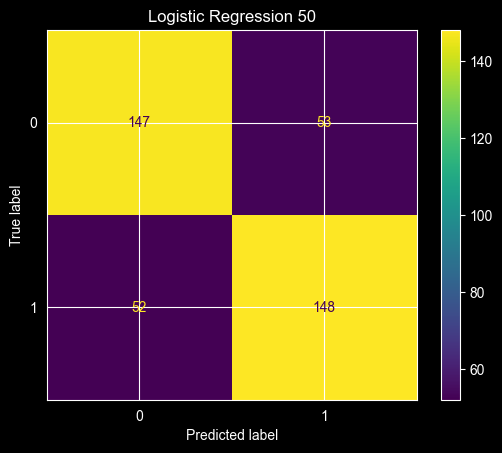


WORD2VEC: 100

Logistic Regression
Accuracy: 0.75
[[149  51]
 [ 49 151]]

KNN
0.685
[[138  62]
 [ 64 136]]


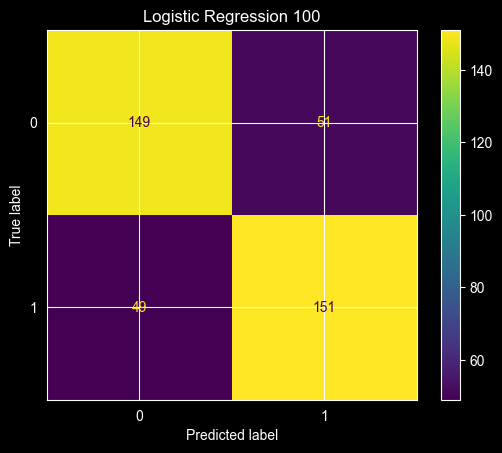


WORD2VEC: 200

Logistic Regression
Accuracy: 0.76
[[148  52]
 [ 44 156]]

KNN
0.705
[[144  56]
 [ 62 138]]


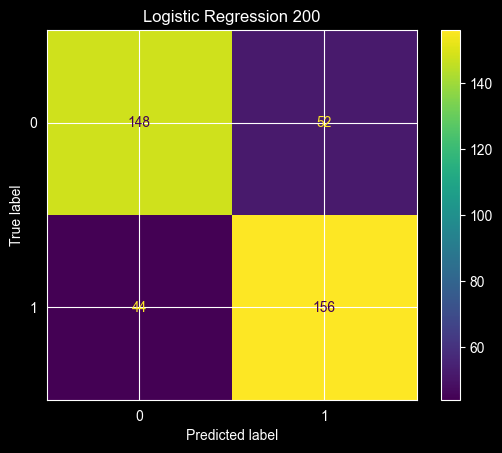

In [7]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from nltk.corpus import movie_reviews
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import LabelEncoder

from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec


######################################################
# PATHS
######################################################

BBC_PATH = r"C:\Users\Almahdi\Desktop\NLP_MohammadAminKiani_4043644008\code\bbc"

GLOVE_PATH = r"C:\Users\Almahdi\Desktop\NLP_MohammadAminKiani_4043644008\code\glove"

RANDOM_STATE = 42

VECTOR_SIZES = [50,100,200]

TOKEN_PATTERN = re.compile(r"[a-z]+")


######################################################
# PREPROCESS
######################################################

def preprocess(text):

    return TOKEN_PATTERN.findall(text.lower())


######################################################
# DOCUMENT VECTOR
######################################################

# def document_vector(words, model):
#
#     vectors = []
#
#     for w in words:
#
#         if w in model:
#
#             vectors.append(model[w])
#
#     if len(vectors) == 0:
#
#         return np.zeros(model.vector_size)
#
#     return np.mean(vectors, axis=0)

def document_vector(words, model):

    vectors = []

    for w in words:

        if w in model.key_to_index:
            vectors.append(model[w])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)


######################################################
# PART 1
######################################################

print("\n==============================")
print("PART 1 : MOVIE REVIEWS")
print("==============================")

docs = []
labels = []

for fileid in movie_reviews.fileids():

    words = movie_reviews.words(fileid)

    text = " ".join(words)

    docs.append(preprocess(text))

    labels.append(movie_reviews.categories(fileid)[0])

y = np.array([1 if x=="pos" else 0 for x in labels])

X_train_docs, X_test_docs, y_train, y_test = train_test_split(
    docs,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

for dim in VECTOR_SIZES:

    print("\nWORD2VEC:",dim)

    w2v = Word2Vec(
        sentences=X_train_docs,
        vector_size=dim,
        window=5,
        min_count=2,
        workers=4,
        sg=1,
        epochs=10,
        seed=RANDOM_STATE
    )

    X_train = np.array([
        document_vector(doc,w2v.wv)
        for doc in X_train_docs
    ])

    X_test = np.array([
        document_vector(doc,w2v.wv)
        for doc in X_test_docs
    ])

    ##################################################
    # Logistic Regression
    ##################################################

    lr = LogisticRegression(max_iter=3000)

    lr.fit(X_train,y_train)

    pred_lr = lr.predict(X_test)

    print("\nLogistic Regression")

    print(
        "Accuracy:",
        accuracy_score(y_test,pred_lr)
    )

    print(
        confusion_matrix(y_test,pred_lr)
    )

    ##################################################
    # KNN
    ##################################################

    knn = KNeighborsClassifier(
        n_neighbors=7, # 1, 3, 5, 7
        metric="cosine"
    )

    knn.fit(X_train,y_train)

    pred_knn = knn.predict(X_test)

    print("\nKNN")

    print(
        accuracy_score(y_test,pred_knn)
    )

    print(
        confusion_matrix(y_test,pred_knn)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix(y_test,pred_lr)
    )

    disp.plot()

    plt.title(
        f"Logistic Regression {dim}"
    )

    plt.show()



PART 1 : MOVIE REVIEWS

WORD2VEC: 50

Logistic Regression
Accuracy: 0.7325
[[149  51]
 [ 56 144]]

KNN
0.67
[[144  56]
 [ 76 124]]


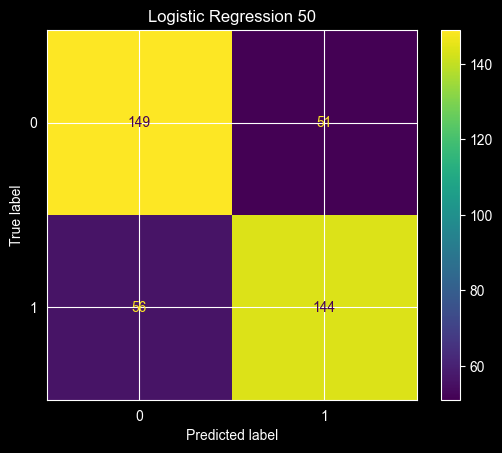


WORD2VEC: 100

Logistic Regression
Accuracy: 0.745
[[151  49]
 [ 53 147]]

KNN
0.7
[[147  53]
 [ 67 133]]


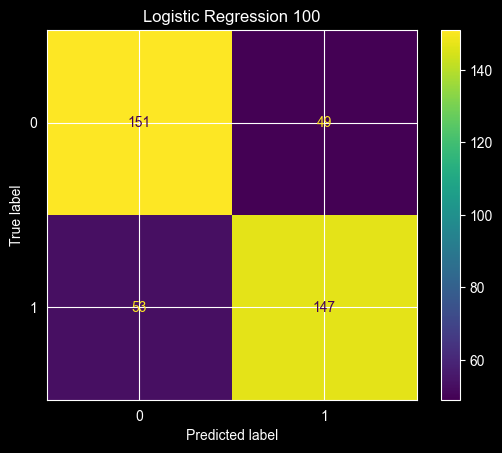


WORD2VEC: 200

Logistic Regression
Accuracy: 0.74
[[149  51]
 [ 53 147]]

KNN
0.6975
[[146  54]
 [ 67 133]]


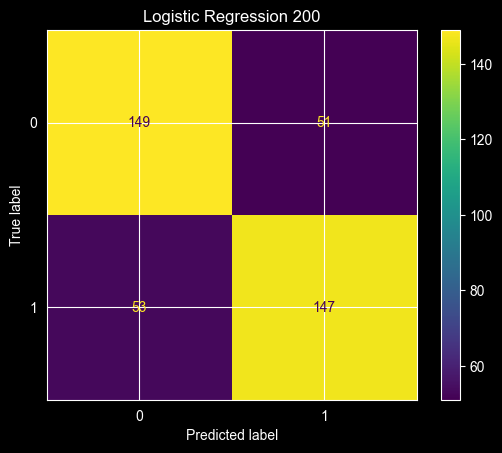

In [2]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from nltk.corpus import movie_reviews
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import LabelEncoder

from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
from sklearn.preprocessing import normalize

######################################################
# PATHS
######################################################

BBC_PATH = r"C:\Users\Almahdi\Desktop\NLP_MohammadAminKiani_4043644008\code\bbc"

GLOVE_PATH = r"C:\Users\Almahdi\Desktop\NLP_MohammadAminKiani_4043644008\code\glove"

RANDOM_STATE = 42

VECTOR_SIZES = [50,100,200]

TOKEN_PATTERN = re.compile(r"[a-z]+")


######################################################
# PREPROCESS
######################################################

def preprocess(text):

    return TOKEN_PATTERN.findall(text.lower())


######################################################
# DOCUMENT VECTOR
######################################################

# def document_vector(words, model):
#
#     vectors = []
#
#     for w in words:
#
#         if w in model:
#
#             vectors.append(model[w])
#
#     if len(vectors) == 0:
#
#         return np.zeros(model.vector_size)
#
#     return np.mean(vectors, axis=0)

def document_vector(words, model):

    vectors = []

    for w in words:

        if w in model.key_to_index:
            vectors.append(model[w])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)


######################################################
# PART 1
######################################################

print("\n==============================")
print("PART 1 : MOVIE REVIEWS")
print("==============================")

docs = []
labels = []

for fileid in movie_reviews.fileids():

    words = movie_reviews.words(fileid)

    text = " ".join(words)

    docs.append(preprocess(text))

    labels.append(movie_reviews.categories(fileid)[0])

y = np.array([1 if x=="pos" else 0 for x in labels])

X_train_docs, X_test_docs, y_train, y_test = train_test_split(
    docs,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

for dim in VECTOR_SIZES:

    print("\nWORD2VEC:",dim)

    w2v = Word2Vec(
        sentences=X_train_docs,
        vector_size=dim,
        window=5,
        min_count=2,
        workers=4,
        sg=1,
        epochs=10,
        seed=RANDOM_STATE
    )

    X_train = np.array([
        document_vector(doc,w2v.wv)
        for doc in X_train_docs
    ])

    X_test = np.array([
        document_vector(doc,w2v.wv)
        for doc in X_test_docs
    ])

    ##################################################
    # L2 Normalization
    ##################################################

    X_train = normalize(X_train, norm="l2")
    X_test = normalize(X_test, norm="l2")

    ##################################################
    # Logistic Regression
    ##################################################

    lr = LogisticRegression(max_iter=3000)

    lr.fit(X_train,y_train)

    pred_lr = lr.predict(X_test)

    print("\nLogistic Regression")

    print(
        "Accuracy:",
        accuracy_score(y_test,pred_lr)
    )

    print(
        confusion_matrix(y_test,pred_lr)
    )

    ##################################################
    # KNN
    ##################################################

    knn = KNeighborsClassifier(
        n_neighbors=7, # 1, 3, 5, 7
        metric="cosine"
    )

    knn.fit(X_train,y_train)

    pred_knn = knn.predict(X_test)

    print("\nKNN")

    print(
        accuracy_score(y_test,pred_knn)
    )

    print(
        confusion_matrix(y_test,pred_knn)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix(y_test,pred_lr)
    )

    disp.plot()

    plt.title(
        f"Logistic Regression {dim}"
    )

    plt.show()


### Part 1.2 – BBC News + pre-trained GloVe

In [4]:
# ============================================================
# Part 1.2 – BBC News + pre-trained GloVe
# ============================================================

def load_bbc_fulltext(bbc_root: Path) -> Tuple[List[List[str]], np.ndarray, List[str]]:
    """
    Expects subfolders named by class labels.
    Reads every .txt file under each class folder.
    """
    if not bbc_root.exists():
        raise FileNotFoundError(f"BBC folder not found: {bbc_root}")

    docs: List[List[str]] = []
    labels: List[str] = []

    class_dirs = [p for p in bbc_root.iterdir() if p.is_dir()]
    if not class_dirs:
        raise FileNotFoundError(f"No class subfolders found under: {bbc_root}")

    for class_dir in sorted(class_dirs):
        for txt_file in sorted(class_dir.glob("*.txt")):
            text = txt_file.read_text(encoding="latin-1", errors="ignore")
            tokens = preprocess_text(text)
            docs.append(tokens)
            labels.append(class_dir.name)

    return docs, np.array(labels), sorted(set(labels))


def load_glove_vectors(dim: int) -> KeyedVectors:
    """
    Load GloVe vectors of a given dimension.
    Converts from GloVe txt to word2vec format once if needed.
    """
    text_path = None
    for candidate in GLOVE_TEXT_CANDIDATES.get(dim, []):
        if candidate.exists():
            text_path = candidate
            break

    if text_path is None:
        raise FileNotFoundError(
            f"Could not find a GloVe {dim}d text file. "
            f"Expected one of: {GLOVE_TEXT_CANDIDATES.get(dim, [])}"
        )

    converted_path = text_path.with_suffix(".word2vec.txt")
    if not converted_path.exists():
        print(f"Converting {text_path.name} -> {converted_path.name} (one-time)...")
        glove2word2vec(str(text_path), str(converted_path))

    kv = KeyedVectors.load_word2vec_format(str(converted_path), binary=False)
    return kv


def run_multiclass_eval(X_train: np.ndarray, X_test: np.ndarray, y_train: np.ndarray, y_test: np.ndarray, labels: Sequence[str]) -> Dict[str, Dict[str, float]]:
    results = {}

    lr = LogisticRegression(
        max_iter=4000,
        random_state=RANDOM_STATE,
        multi_class="ovr",
        n_jobs=None,
    )
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    results["LogisticRegression_OVR"] = print_eval("Logistic Regression (OvR)", y_test, y_pred_lr, labels)

    svm = LinearSVC(random_state=RANDOM_STATE)
    svm.fit(X_train, y_train)
    y_pred_svm = svm.predict(X_test)
    results["LinearSVC"] = print_eval("Linear SVM", y_test, y_pred_svm, labels)

    return results


def run_part_1_2() -> None:
    print("\n" + "=" * 80)
    print("PART 1.2 – BBC News with pre-trained GloVe")
    print("=" * 80)

    bbc_root = resolve_existing_path(BBC_DIR_CANDIDATES)
    docs, y_str, class_names = load_bbc_fulltext(bbc_root)
    print(f"Loaded BBC documents: {len(docs)}")
    print(f"Classes: {class_names}")

    le = LabelEncoder()
    y = le.fit_transform(y_str)

    X_train_docs, X_test_docs, y_train, y_test = train_test_split(
        docs,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    print(f"Train docs: {len(X_train_docs)} | Test docs: {len(X_test_docs)}")

    # Use the highest-dimensional GloVe file available among the listed candidates.
    available_dims = [d for d in [50, 100, 200, 300] if any(p.exists() for p in GLOVE_TEXT_CANDIDATES.get(d, []))]
    if not available_dims:
        raise FileNotFoundError("No GloVe .txt file found. Place glove.6B.{50,100,200,300}d.txt in the script folder.")

    print(f"Available GloVe dimensions detected: {available_dims}")

    summary_rows = []
    for dim in available_dims:
        print(f"\n--- Loading GloVe {dim}d ---")
        kv = load_glove_vectors(dim)

        cov = oov_coverage(X_train_docs + X_test_docs, kv)
        print(
            f"OOV token percentage: {cov['token_oov_pct']:.2f}% | "
            f"Coverage: {cov['token_coverage_pct']:.2f}% | "
            f"OOV type percentage: {cov['type_oov_pct']:.2f}%"
        )

        X_train = texts_to_matrix(X_train_docs, kv)
        X_test = texts_to_matrix(X_test_docs, kv)

        results = run_multiclass_eval(X_train, X_test, y_train, y_test, class_names)

        summary_rows.append(
            {
                "glove_dim": dim,
                "oov_token_pct": cov["token_oov_pct"],
                "lr_acc": results["LogisticRegression_OVR"]["accuracy"],
                "lr_macro_f1": results["LogisticRegression_OVR"]["macro_f1"],
                "svm_acc": results["LinearSVC"]["accuracy"],
                "svm_macro_f1": results["LinearSVC"]["macro_f1"],
            }
        )

    print("\nSummary for GloVe sizes:")
    for row in summary_rows:
        print(row)

    print(
        "\nInterpretation hint:\n"
        "- Adding more embedding dimensions does not always improve accuracy.\n"
        "- 50d may be faster and sometimes enough; 100d often balances quality and speed.\n"
        "- For BBC news, linear classifiers usually work well with averaged embeddings.\n"
        "- Lower OOV means better lexical coverage, but accuracy still depends on class separability."
    )


GLOVE 50
OOV Percentage: 0.21

Logistic Regression
0.9573033707865168
               precision    recall  f1-score   support

     business       0.94      0.94      0.94       102
entertainment       0.96      1.00      0.98        77
     politics       0.92      0.90      0.91        84
        sport       1.00      0.98      0.99       102
         tech       0.96      0.96      0.96        80

     accuracy                           0.96       445
    macro avg       0.96      0.96      0.96       445
 weighted avg       0.96      0.96      0.96       445


Linear SVM
0.9662921348314607
               precision    recall  f1-score   support

     business       0.96      0.95      0.96       102
entertainment       0.99      0.99      0.99        77
     politics       0.93      0.94      0.93        84
        sport       1.00      0.99      1.00       102
         tech       0.95      0.96      0.96        80

     accuracy                           0.97       445
    macro avg

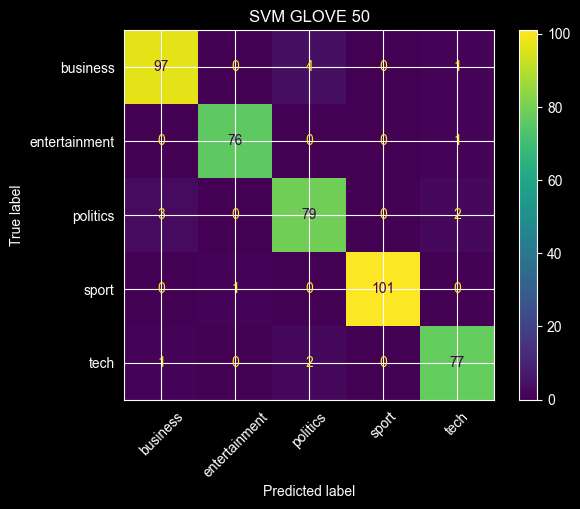


GLOVE 100
OOV Percentage: 0.21

Logistic Regression
0.9617977528089887
               precision    recall  f1-score   support

     business       0.97      0.94      0.96       102
entertainment       0.95      0.99      0.97        77
     politics       0.92      0.94      0.93        84
        sport       1.00      0.99      1.00       102
         tech       0.96      0.95      0.96        80

     accuracy                           0.96       445
    macro avg       0.96      0.96      0.96       445
 weighted avg       0.96      0.96      0.96       445


Linear SVM
0.9842696629213483
               precision    recall  f1-score   support

     business       0.99      0.97      0.98       102
entertainment       0.99      1.00      0.99        77
     politics       0.98      0.98      0.98        84
        sport       1.00      1.00      1.00       102
         tech       0.96      0.97      0.97        80

     accuracy                           0.98       445
    macro av

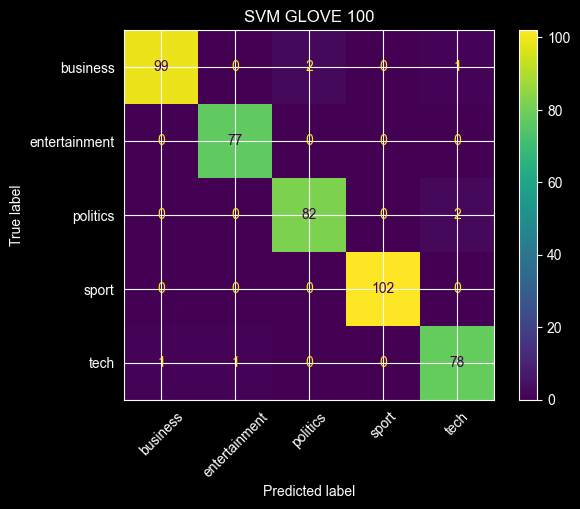


GLOVE 200
OOV Percentage: 0.21

Logistic Regression
0.9640449438202248
               precision    recall  f1-score   support

     business       0.97      0.95      0.96       102
entertainment       0.96      0.99      0.97        77
     politics       0.92      0.94      0.93        84
        sport       1.00      0.99      1.00       102
         tech       0.96      0.95      0.96        80

     accuracy                           0.96       445
    macro avg       0.96      0.96      0.96       445
 weighted avg       0.96      0.96      0.96       445


Linear SVM
0.9842696629213483
               precision    recall  f1-score   support

     business       0.99      0.97      0.98       102
entertainment       0.99      1.00      0.99        77
     politics       0.98      0.98      0.98        84
        sport       1.00      1.00      1.00       102
         tech       0.96      0.97      0.97        80

     accuracy                           0.98       445
    macro av

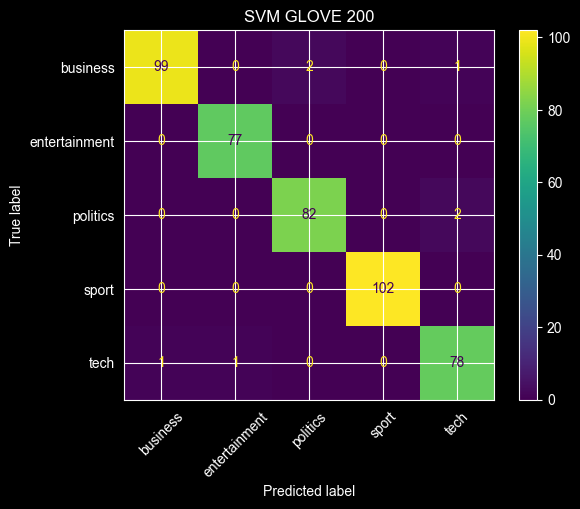


GLOVE 300
OOV Percentage: 0.21

Logistic Regression
0.9662921348314607
               precision    recall  f1-score   support

     business       0.98      0.95      0.97       102
entertainment       0.96      0.99      0.97        77
     politics       0.92      0.95      0.94        84
        sport       1.00      0.99      1.00       102
         tech       0.96      0.95      0.96        80

     accuracy                           0.97       445
    macro avg       0.96      0.97      0.97       445
 weighted avg       0.97      0.97      0.97       445


Linear SVM
0.9842696629213483
               precision    recall  f1-score   support

     business       0.99      0.97      0.98       102
entertainment       0.99      1.00      0.99        77
     politics       0.98      0.98      0.98        84
        sport       1.00      1.00      1.00       102
         tech       0.96      0.97      0.97        80

     accuracy                           0.98       445
    macro av

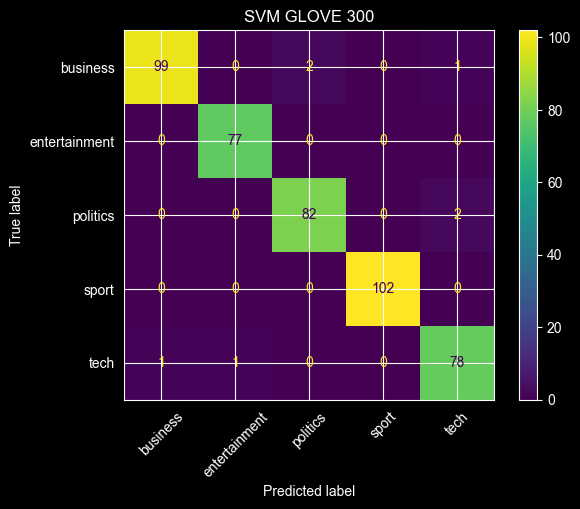


DONE.


In [13]:

######################################################
# GLOVE LOOP
######################################################

for dim in [50,100,200,300]:

    print("\n===================")
    print("GLOVE",dim)
    print("===================")

    glove_file = os.path.join(
        GLOVE_PATH,
        f"glove.6B.{dim}d.txt"
    )

    converted = os.path.join(
        GLOVE_PATH,
        f"glove.{dim}.txt"
    )

    # if not os.path.exists(converted):
    #
    #     glove2word2vec(
    #         glove_file,
    #         converted
    #     )
    #
    # model = KeyedVectors.load_word2vec_format(
    #     converted,
    #     binary=False
    # )

    # https://groups.google.com/g/gensim/c/G40gps4ngPw
    model = KeyedVectors.load_word2vec_format(
        glove_file,
        binary=False,
        no_header=True
    )

    ##################################################
    # OOV
    ##################################################

    total = 0
    oov = 0

    for doc in texts:

        for word in doc:

            total += 1

            if word not in model:

                oov += 1

    print(
        "OOV Percentage:",
        round(100*oov/total,2)
    )

    ##################################################
    # DOCUMENT EMBEDDINGS
    ##################################################

    X_train = np.array([
        document_vector(doc,model)
        for doc in X_train_docs
    ])

    X_test = np.array([
        document_vector(doc,model)
        for doc in X_test_docs
    ])

    ##################################################
    # Logistic Regression
    ##################################################

    lr = LogisticRegression(
        max_iter=5000,
        multi_class="ovr"
    )

    lr.fit(X_train,y_train)

    pred_lr = lr.predict(X_test)

    print("\nLogistic Regression")

    print(
        accuracy_score(y_test,pred_lr)
    )

    print(
        classification_report(
            y_test,
            pred_lr,
            target_names=encoder.classes_
        )
    )

    ##################################################
    # SVM
    ##################################################

    svm = LinearSVC(
        dual=False,
        random_state=42
    )

    svm.fit(X_train,y_train)

    pred_svm = svm.predict(X_test)

    print("\nLinear SVM")

    print(
        accuracy_score(y_test,pred_svm)
    )

    print(
        classification_report(
            y_test,
            pred_svm,
            target_names=encoder.classes_
        )
    )

    cm = confusion_matrix(
        y_test,
        pred_svm
    )

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=encoder.classes_
    )

    disp.plot(
        xticks_rotation=45
    )

    plt.title(
        f"SVM GLOVE {dim}"
    )

    plt.show()

print("\nDONE.")


GLOVE 50
OOV Percentage: 0.21

Logistic Regression
0.9370786516853933
               precision    recall  f1-score   support

     business       0.90      0.93      0.92       102
entertainment       0.96      0.96      0.96        77
     politics       0.88      0.87      0.87        84
        sport       0.99      0.97      0.98       102
         tech       0.95      0.95      0.95        80

     accuracy                           0.94       445
    macro avg       0.94      0.94      0.94       445
 weighted avg       0.94      0.94      0.94       445


Linear SVM
0.9640449438202248
               precision    recall  f1-score   support

     business       0.96      0.94      0.95       102
entertainment       0.96      1.00      0.98        77
     politics       0.93      0.93      0.93        84
        sport       1.00      0.99      1.00       102
         tech       0.96      0.96      0.96        80

     accuracy                           0.96       445
    macro avg

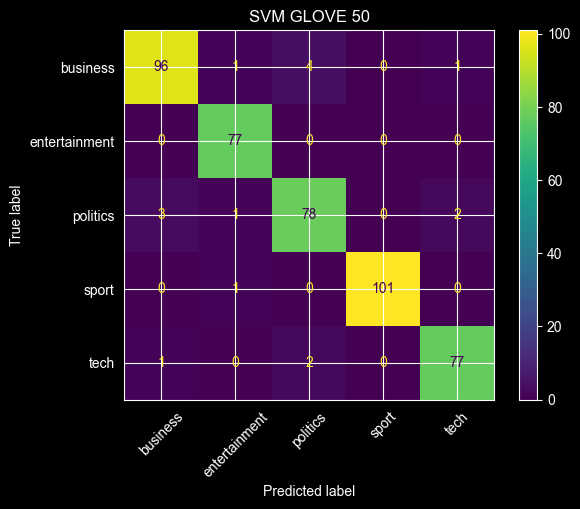


GLOVE 100
OOV Percentage: 0.21

Logistic Regression
0.9348314606741573
               precision    recall  f1-score   support

     business       0.90      0.93      0.92       102
entertainment       0.95      0.96      0.95        77
     politics       0.88      0.87      0.87        84
        sport       0.99      0.97      0.98       102
         tech       0.95      0.94      0.94        80

     accuracy                           0.93       445
    macro avg       0.93      0.93      0.93       445
 weighted avg       0.94      0.93      0.93       445


Linear SVM
0.9662921348314607
               precision    recall  f1-score   support

     business       0.98      0.95      0.97       102
entertainment       0.96      0.99      0.97        77
     politics       0.92      0.95      0.94        84
        sport       1.00      0.99      1.00       102
         tech       0.96      0.95      0.96        80

     accuracy                           0.97       445
    macro av

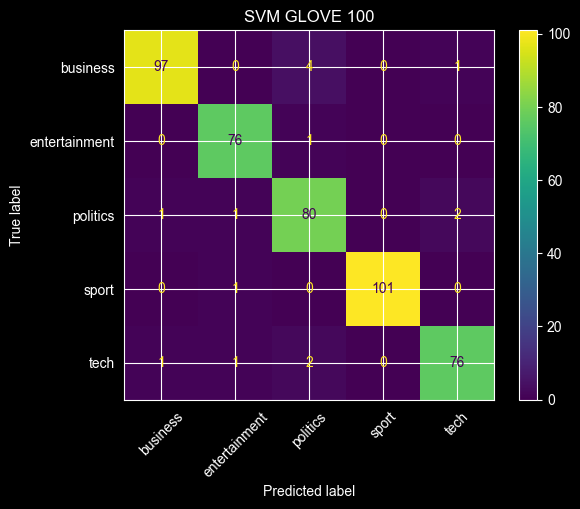


GLOVE 200
OOV Percentage: 0.21

Logistic Regression
0.9370786516853933
               precision    recall  f1-score   support

     business       0.91      0.93      0.92       102
entertainment       0.95      0.96      0.95        77
     politics       0.88      0.88      0.88        84
        sport       0.99      0.97      0.98       102
         tech       0.95      0.94      0.94        80

     accuracy                           0.94       445
    macro avg       0.94      0.94      0.94       445
 weighted avg       0.94      0.94      0.94       445


Linear SVM
0.9685393258426966
               precision    recall  f1-score   support

     business       0.98      0.95      0.97       102
entertainment       0.97      0.99      0.98        77
     politics       0.92      0.95      0.94        84
        sport       1.00      1.00      1.00       102
         tech       0.96      0.95      0.96        80

     accuracy                           0.97       445
    macro av

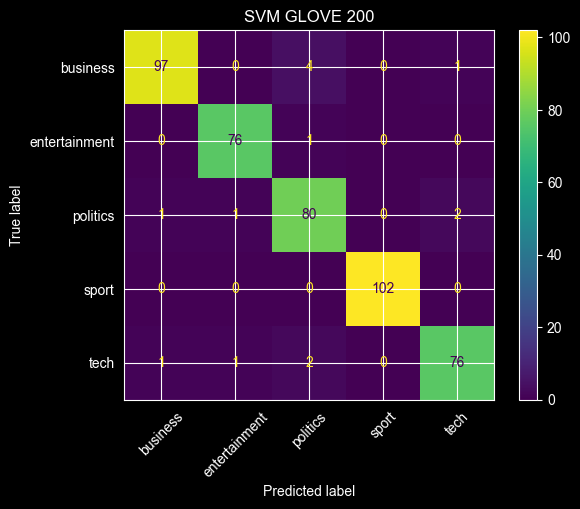


GLOVE 300
OOV Percentage: 0.21

Logistic Regression
0.9483146067415731
               precision    recall  f1-score   support

     business       0.94      0.93      0.94       102
entertainment       0.95      0.97      0.96        77
     politics       0.89      0.92      0.90        84
        sport       1.00      0.98      0.99       102
         tech       0.96      0.94      0.95        80

     accuracy                           0.95       445
    macro avg       0.95      0.95      0.95       445
 weighted avg       0.95      0.95      0.95       445


Linear SVM
0.9707865168539326
               precision    recall  f1-score   support

     business       0.98      0.95      0.97       102
entertainment       0.99      0.99      0.99        77
     politics       0.92      0.96      0.94        84
        sport       1.00      1.00      1.00       102
         tech       0.96      0.95      0.96        80

     accuracy                           0.97       445
    macro av

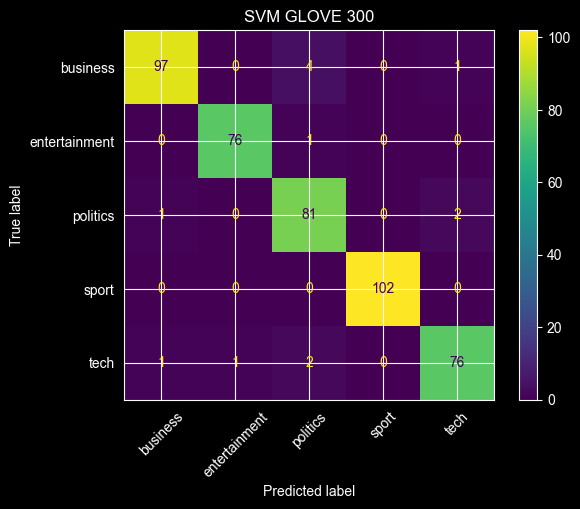


DONE.


In [14]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from nltk.corpus import movie_reviews
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import LabelEncoder

from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
from sklearn.preprocessing import normalize

######################################################
# PATHS
######################################################

BBC_PATH = r"C:\Users\Almahdi\Desktop\NLP_MohammadAminKiani_4043644008\code\bbc"

GLOVE_PATH = r"C:\Users\Almahdi\Desktop\NLP_MohammadAminKiani_4043644008\code\glove"

RANDOM_STATE = 42

VECTOR_SIZES = [50,100,200]

TOKEN_PATTERN = re.compile(r"[a-z]+")


######################################################
# PREPROCESS
######################################################

def preprocess(text):

    return TOKEN_PATTERN.findall(text.lower())


######################################################
# DOCUMENT VECTOR
######################################################

# def document_vector(words, model):
#
#     vectors = []
#
#     for w in words:
#
#         if w in model:
#
#             vectors.append(model[w])
#
#     if len(vectors) == 0:
#
#         return np.zeros(model.vector_size)
#
#     return np.mean(vectors, axis=0)

def document_vector(words, model):

    vectors = []

    for w in words:

        if w in model.key_to_index:
            vectors.append(model[w])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

######################################################
# GLOVE LOOP
######################################################

for dim in [50,100,200,300]:

    print("\n===================")
    print("GLOVE",dim)
    print("===================")

    glove_file = os.path.join(
        GLOVE_PATH,
        f"glove.6B.{dim}d.txt"
    )

    converted = os.path.join(
        GLOVE_PATH,
        f"glove.{dim}.txt"
    )

    # if not os.path.exists(converted):
    #
    #     glove2word2vec(
    #         glove_file,
    #         converted
    #     )
    #
    # model = KeyedVectors.load_word2vec_format(
    #     converted,
    #     binary=False
    # )

    # https://groups.google.com/g/gensim/c/G40gps4ngPw
    model = KeyedVectors.load_word2vec_format(
        glove_file,
        binary=False,
        no_header=True
    )

    ##################################################
    # OOV
    ##################################################

    total = 0
    oov = 0

    for doc in texts:

        for word in doc:

            total += 1

            if word not in model:

                oov += 1

    print(
        "OOV Percentage:",
        round(100*oov/total,2)
    )

    ##################################################
    # DOCUMENT EMBEDDINGS
    ##################################################

    X_train = np.array([
        document_vector(doc,model)
        for doc in X_train_docs
    ])

    X_test = np.array([
        document_vector(doc,model)
        for doc in X_test_docs
    ])

    ##################################################
    # L2 Normalization
    ##################################################

    X_train = normalize(X_train, norm="l2")
    X_test = normalize(X_test, norm="l2")

    ##################################################
    # Logistic Regression
    ##################################################

    lr = LogisticRegression(
        max_iter=5000,
        multi_class="ovr"
    )

    lr.fit(X_train,y_train)

    pred_lr = lr.predict(X_test)

    print("\nLogistic Regression")

    print(
        accuracy_score(y_test,pred_lr)
    )

    print(
        classification_report(
            y_test,
            pred_lr,
            target_names=encoder.classes_
        )
    )

    ##################################################
    # SVM
    ##################################################

    svm = LinearSVC(
        dual=False,
        random_state=42
    )

    svm.fit(X_train,y_train)

    pred_svm = svm.predict(X_test)

    print("\nLinear SVM")

    print(
        accuracy_score(y_test,pred_svm)
    )

    print(
        classification_report(
            y_test,
            pred_svm,
            target_names=encoder.classes_
        )
    )

    ##################################################
    # Confusion Matrix
    ##################################################

    cm_lr = confusion_matrix(
        y_test,
        pred_lr
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_lr,
        display_labels=encoder.classes_
    )

    disp.plot(xticks_rotation=45)

    plt.title(f"Logistic Regression - GloVe {dim}")

    plt.show()

    cm = confusion_matrix(
        y_test,
        pred_svm
    )

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=encoder.classes_
    )

    disp.plot(
        xticks_rotation=45
    )

    plt.title(
        f"SVM GLOVE {dim}"
    )

    plt.show()

print("\nDONE.")

افزایش واژگان (Vocabulary Expansion / OOV Reduction)


GLOVE 50
Training Word2Vec on BBC Corpus ...
OOV Before : 0.21 %
OOV After  : 0.0 %

Logistic Regression
0.9370786516853933
               precision    recall  f1-score   support

     business       0.90      0.93      0.92       102
entertainment       0.96      0.96      0.96        77
     politics       0.88      0.87      0.87        84
        sport       0.99      0.97      0.98       102
         tech       0.95      0.95      0.95        80

     accuracy                           0.94       445
    macro avg       0.94      0.94      0.94       445
 weighted avg       0.94      0.94      0.94       445


Linear SVM
0.9640449438202248
               precision    recall  f1-score   support

     business       0.96      0.94      0.95       102
entertainment       0.96      1.00      0.98        77
     politics       0.93      0.93      0.93        84
        sport       1.00      0.99      1.00       102
         tech       0.96      0.96      0.96        80

     accuracy 

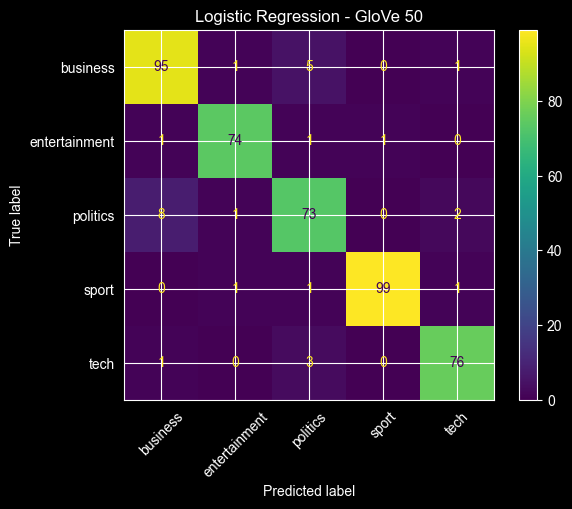

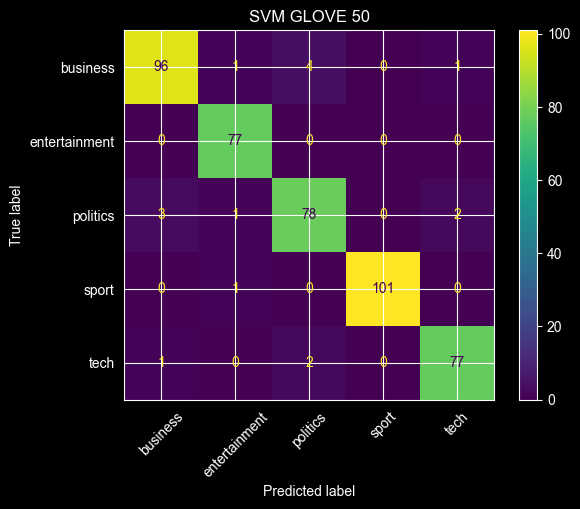


GLOVE 100
Training Word2Vec on BBC Corpus ...
OOV Before : 0.21 %
OOV After  : 0.0 %

Logistic Regression
0.9348314606741573
               precision    recall  f1-score   support

     business       0.90      0.93      0.92       102
entertainment       0.95      0.96      0.95        77
     politics       0.88      0.87      0.87        84
        sport       0.99      0.97      0.98       102
         tech       0.95      0.94      0.94        80

     accuracy                           0.93       445
    macro avg       0.93      0.93      0.93       445
 weighted avg       0.94      0.93      0.93       445


Linear SVM
0.9662921348314607
               precision    recall  f1-score   support

     business       0.98      0.95      0.97       102
entertainment       0.96      0.99      0.97        77
     politics       0.92      0.95      0.94        84
        sport       1.00      0.99      1.00       102
         tech       0.96      0.95      0.96        80

     accuracy

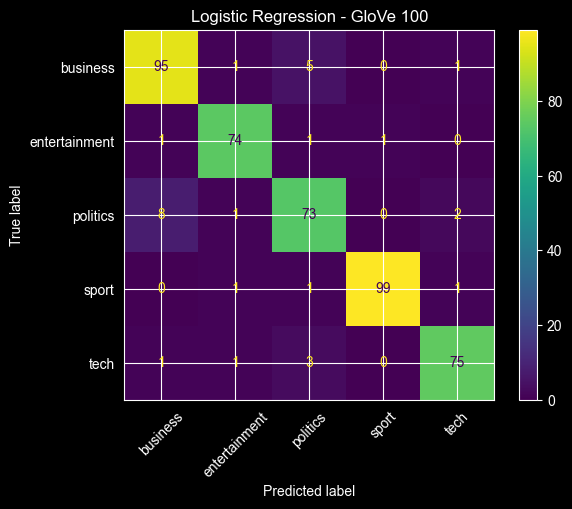

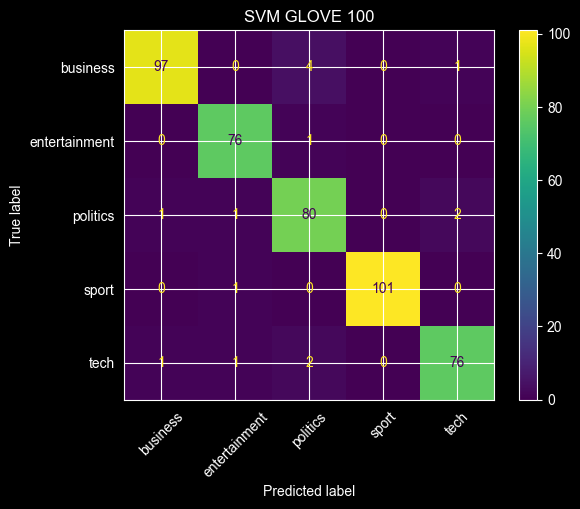


GLOVE 200
Training Word2Vec on BBC Corpus ...
OOV Before : 0.21 %
OOV After  : 0.0 %

Logistic Regression
0.9370786516853933
               precision    recall  f1-score   support

     business       0.91      0.93      0.92       102
entertainment       0.95      0.96      0.95        77
     politics       0.88      0.88      0.88        84
        sport       0.99      0.97      0.98       102
         tech       0.95      0.94      0.94        80

     accuracy                           0.94       445
    macro avg       0.94      0.94      0.94       445
 weighted avg       0.94      0.94      0.94       445


Linear SVM
0.9685393258426966
               precision    recall  f1-score   support

     business       0.98      0.95      0.97       102
entertainment       0.97      0.99      0.98        77
     politics       0.92      0.95      0.94        84
        sport       1.00      1.00      1.00       102
         tech       0.96      0.95      0.96        80

     accuracy

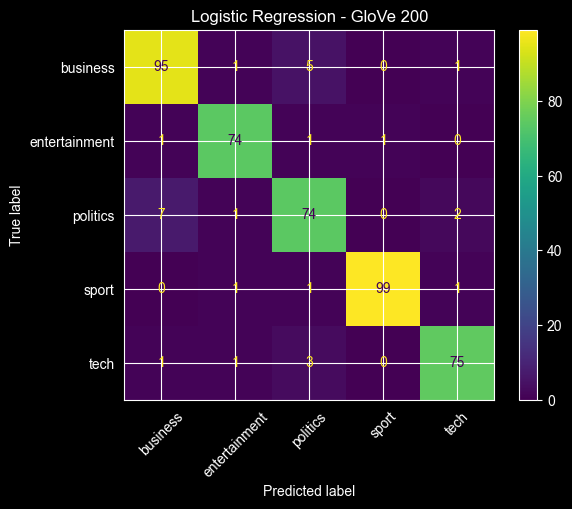

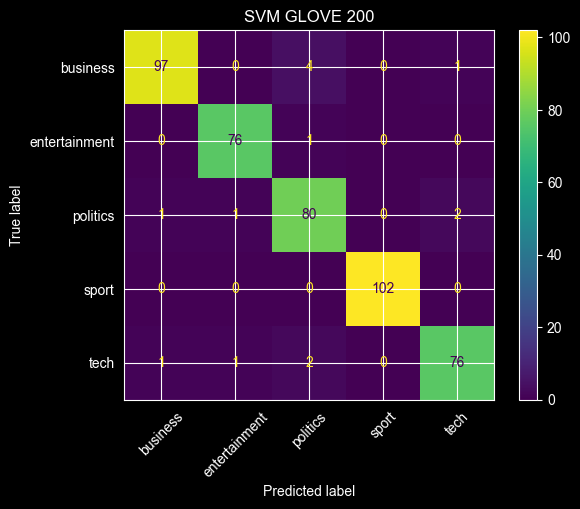


GLOVE 300
Training Word2Vec on BBC Corpus ...
OOV Before : 0.21 %
OOV After  : 0.0 %

Logistic Regression
0.9483146067415731
               precision    recall  f1-score   support

     business       0.94      0.93      0.94       102
entertainment       0.95      0.97      0.96        77
     politics       0.89      0.92      0.90        84
        sport       1.00      0.98      0.99       102
         tech       0.96      0.94      0.95        80

     accuracy                           0.95       445
    macro avg       0.95      0.95      0.95       445
 weighted avg       0.95      0.95      0.95       445


Linear SVM
0.9707865168539326
               precision    recall  f1-score   support

     business       0.98      0.95      0.97       102
entertainment       0.99      0.99      0.99        77
     politics       0.92      0.96      0.94        84
        sport       1.00      1.00      1.00       102
         tech       0.96      0.95      0.96        80

     accuracy

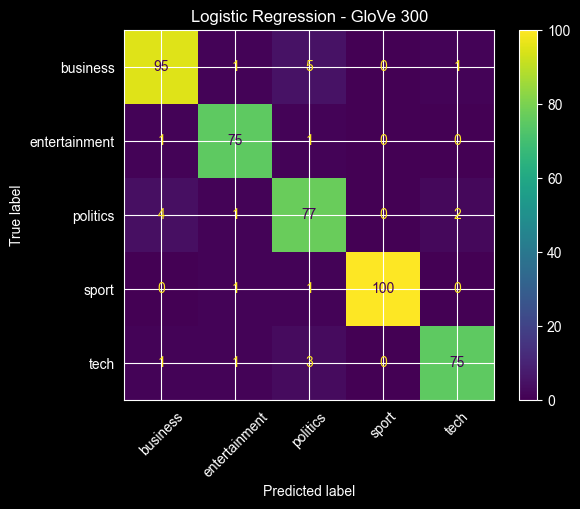

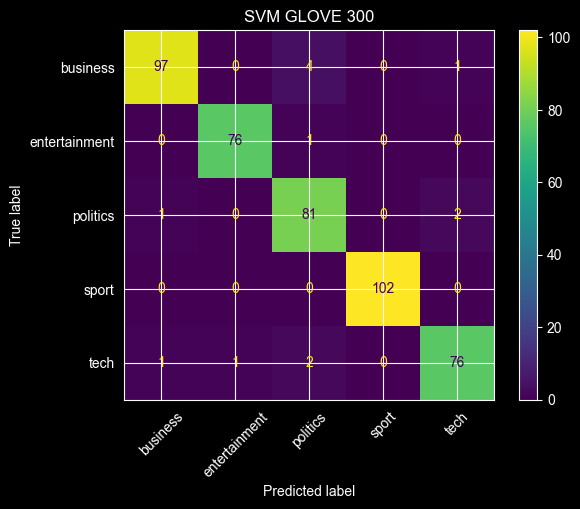


DONE.


In [6]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from nltk.corpus import movie_reviews
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import LabelEncoder

from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
from sklearn.preprocessing import normalize

######################################################
# PATHS
######################################################

BBC_PATH = r"C:\Users\Almahdi\Desktop\NLP_MohammadAminKiani_4043644008\code\bbc"

GLOVE_PATH = r"C:\Users\Almahdi\Desktop\NLP_MohammadAminKiani_4043644008\code\glove"

RANDOM_STATE = 42

VECTOR_SIZES = [50,100,200]

TOKEN_PATTERN = re.compile(r"[a-z]+")


######################################################
# PREPROCESS
######################################################

def preprocess(text):

    return TOKEN_PATTERN.findall(text.lower())


######################################################
# DOCUMENT VECTOR
######################################################

# def document_vector(words, model):
#
#     vectors = []
#
#     for w in words:
#
#         if w in model:
#
#             vectors.append(model[w])
#
#     if len(vectors) == 0:
#
#         return np.zeros(model.vector_size)
#
#     return np.mean(vectors, axis=0)

# def document_vector(words, model):
#
#     vectors = []
#
#     for w in words:
#
#         if w in model.key_to_index:
#             vectors.append(model[w])
#
#     if len(vectors) == 0:
#         return np.zeros(model.vector_size)
#
#     return np.mean(vectors, axis=0)


def document_vector(words, glove_model, w2v_model=None):

    vectors = []

    for word in words:

        ################################################
        # موجود در GloVe
        ################################################
        if word in glove_model.key_to_index:

            vectors.append(glove_model[word])

        ################################################
        # موجود نبود → از Word2Vec استفاده کن
        ################################################
        elif w2v_model is not None and word in w2v_model.wv.key_to_index:

            vectors.append(w2v_model.wv[word])

    if len(vectors)==0:

        return np.zeros(glove_model.vector_size)

    return np.mean(vectors,axis=0)


######################################################
# GLOVE LOOP
######################################################

for dim in [50,100,200,300]:

    print("\n===================")
    print("GLOVE",dim)
    print("===================")

    glove_file = os.path.join(
        GLOVE_PATH,
        f"glove.6B.{dim}d.txt"
    )

    converted = os.path.join(
        GLOVE_PATH,
        f"glove.{dim}.txt"
    )

    # if not os.path.exists(converted):
    #
    #     glove2word2vec(
    #         glove_file,
    #         converted
    #     )
    #
    # model = KeyedVectors.load_word2vec_format(
    #     converted,
    #     binary=False
    # )

    # https://groups.google.com/g/gensim/c/G40gps4ngPw
    model = KeyedVectors.load_word2vec_format(
        glove_file,
        binary=False,
        no_header=True
    )

    ##################################################
    # Train Word2Vec on BBC (for OOV Reduction)
    ##################################################

    print("Training Word2Vec on BBC Corpus ...")

    bbc_w2v = Word2Vec(
        sentences=texts,
        vector_size=dim,
        window=5,
        min_count=1,
        workers=4,
        sg=1,
        epochs=20,
        seed=42
    )

    ##################################################
    # OOV
    ##################################################

    # total = 0
    # oov = 0
    #
    # for doc in texts:
    #
    #     for word in doc:
    #
    #         total += 1
    #
    #         if word not in model:
    #
    #             oov += 1
    #
    # print(
    #     "OOV Percentage:",
    #     round(100*oov/total,2)
    # )

    ##################################################
    # OOV Before / After
    ##################################################

    before = 0
    after = 0
    total = 0

    for doc in texts:

        for word in doc:

            total += 1

            if word not in model:

                before += 1

                if word not in bbc_w2v.wv:

                    after += 1

    print("="*40)
    print("OOV Before :", round(100*before/total,2),"%")
    print("OOV After  :", round(100*after/total,2),"%")
    print("="*40)

    ##################################################
    # DOCUMENT EMBEDDINGS
    ##################################################

    # X_train = np.array([
    #     document_vector(doc,model)
    #     for doc in X_train_docs
    # ])
    #
    # X_test = np.array([
    #     document_vector(doc,model)
    #     for doc in X_test_docs
    # ])

    X_train = np.array([
        document_vector(doc, model, bbc_w2v)
        for doc in X_train_docs
    ])

    X_test = np.array([
        document_vector(doc, model, bbc_w2v)
        for doc in X_test_docs
    ])

    ##################################################
    # L2 Normalization
    ##################################################

    X_train = normalize(X_train, norm="l2")
    X_test = normalize(X_test, norm="l2")

    ##################################################
    # Logistic Regression
    ##################################################

    lr = LogisticRegression(
        max_iter=5000,
        multi_class="ovr"
    )

    lr.fit(X_train,y_train)

    pred_lr = lr.predict(X_test)

    print("\nLogistic Regression")

    print(
        accuracy_score(y_test,pred_lr)
    )

    print(
        classification_report(
            y_test,
            pred_lr,
            target_names=encoder.classes_
        )
    )

    ##################################################
    # SVM
    ##################################################

    svm = LinearSVC(
        dual=False,
        random_state=42
    )

    svm.fit(X_train,y_train)

    pred_svm = svm.predict(X_test)

    print("\nLinear SVM")

    print(
        accuracy_score(y_test,pred_svm)
    )

    print(
        classification_report(
            y_test,
            pred_svm,
            target_names=encoder.classes_
        )
    )

    ##################################################
    # Confusion Matrix
    ##################################################

    cm_lr = confusion_matrix(
        y_test,
        pred_lr
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_lr,
        display_labels=encoder.classes_
    )

    disp.plot(xticks_rotation=45)

    plt.title(f"Logistic Regression - GloVe {dim}")

    plt.show()

    cm = confusion_matrix(
        y_test,
        pred_svm
    )

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=encoder.classes_
    )

    disp.plot(
        xticks_rotation=45
    )

    plt.title(
        f"SVM GLOVE {dim}"
    )

    plt.show()

print("\nDONE.")

✅ Logistic Regression
✅ Linear SVM
✅ KNN
✅ Decision Tree
✅ Random Forest
✅ Gaussian Naive Bayes
✅ XGBoost (در صورت نصب)

 تقریباً تمام خانواده‌های مهم طبقه‌بندی کلاسیک را پوشش می‌دهند.

In [22]:
import xgboost

print(xgboost.__version__)

2.1.4


In [21]:
%pip install xgboost

from xgboost import XGBClassifier

print("XGBoost Installed Successfully")

  Using cached xgboost-2.1.4-py3-none-win_amd64.whl.metadata (2.1 kB)
Note: you may need to restart the kernel to use updated packages.
XGBoost Installed Successfully


ERROR: Could not install packages due to an OSError: HTTPSConnectionPool(host='files.pythonhosted.org', port=443): Max retries exceeded with url: /packages/43/80/0b5a2dfcf5b4da27b0b68d2833f05d77e1a374d43db951fca200a1f12a52/xgboost-2.1.4-py3-none-win_amd64.whl (Caused by ConnectTimeoutError(<pip._vendor.urllib3.connection.HTTPSConnection object at 0x000002BD287893D0>, 'Connection to files.pythonhosted.org timed out. (connect timeout=15)'))


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Almahdi\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip


In [23]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import f1_score

import pandas as pd

try:

    from xgboost import XGBClassifier

    XGB_AVAILABLE = True

except ImportError:

    XGB_AVAILABLE = False

# =======================================

tree = DecisionTreeClassifier(

    random_state=42,

    max_depth=25
)

tree.fit(X_train,y_train)

pred_tree = tree.predict(X_test)

print("\nDecision Tree")

print("Accuracy:",accuracy_score(y_test,pred_tree))

print(classification_report(
    y_test,
    pred_tree,
    target_names=encoder.classes_
))

forest = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1
)

forest.fit(X_train,y_train)

pred_rf = forest.predict(X_test)

print("\nRandom Forest")

print("Accuracy:",accuracy_score(y_test,pred_rf))

print(classification_report(
    y_test,
    pred_rf,
    target_names=encoder.classes_
))

nb = GaussianNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

print("\nGaussian Naive Bayes")

print("Accuracy:",accuracy_score(y_test,pred_nb))

print(classification_report(
    y_test,
    pred_nb,
    target_names=encoder.classes_
))

if XGB_AVAILABLE:

    xgb = XGBClassifier(

        n_estimators=300,

        learning_rate=0.1,

        max_depth=6,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42,

        eval_metric="mlogloss"
    )

    xgb.fit(X_train,y_train)

    pred_xgb = xgb.predict(X_test)

    print("\nXGBoost")

    print("Accuracy:",accuracy_score(y_test,pred_xgb))

    print(classification_report(
        y_test,
        pred_xgb,
        target_names=encoder.classes_
    ))




Decision Tree
Accuracy: 0.8741573033707866
               precision    recall  f1-score   support

     business       0.86      0.87      0.86       102
entertainment       0.84      0.94      0.88        77
     politics       0.83      0.80      0.81        84
        sport       0.97      0.89      0.93       102
         tech       0.88      0.88      0.88        80

     accuracy                           0.87       445
    macro avg       0.87      0.87      0.87       445
 weighted avg       0.88      0.87      0.87       445


Random Forest
Accuracy: 0.9662921348314607
               precision    recall  f1-score   support

     business       0.96      0.94      0.95       102
entertainment       0.96      0.99      0.97        77
     politics       0.94      0.95      0.95        84
        sport       1.00      0.98      0.99       102
         tech       0.96      0.97      0.97        80

     accuracy                           0.97       445
    macro avg       0.97   

In [24]:
results = [

    ["Logistic Regression",
     accuracy_score(y_test,pred_lr),
     f1_score(y_test,pred_lr,average="macro")],

    ["Linear SVM",
     accuracy_score(y_test,pred_svm),
     f1_score(y_test,pred_svm,average="macro")],

    ["Decision Tree",
     accuracy_score(y_test,pred_tree),
     f1_score(y_test,pred_tree,average="macro")],

    ["Random Forest",
     accuracy_score(y_test,pred_rf),
     f1_score(y_test,pred_rf,average="macro")],

    ["Gaussian NB",
     accuracy_score(y_test,pred_nb),
     f1_score(y_test,pred_nb,average="macro")]
]

if XGB_AVAILABLE:

    results.append(

        ["XGBoost",

         accuracy_score(y_test,pred_xgb),

         f1_score(y_test,pred_xgb,average="macro")]

    )

df = pd.DataFrame(

    results,

    columns=[

        "Classifier",

        "Accuracy",

        "Macro F1"
    ]
)

print("\n==============================")

print(df.sort_values(

    "Accuracy",

    ascending=False

))

print("==============================")


            Classifier  Accuracy  Macro F1
5              XGBoost  0.977528  0.977065
1           Linear SVM  0.970787  0.970004
3        Random Forest  0.966292  0.966129
0  Logistic Regression  0.948315  0.947510
4          Gaussian NB  0.948315  0.947926
2        Decision Tree  0.874157  0.872641


### Run

In [10]:
# ============================================================
# Main
# ============================================================

def main() -> None:
    print("Starting Exercise 2 pipeline...\n")
    run_part_1_1()
    # run_part_1_2()  #'WindowsPath' object is not iterable
    print("\nDone.")


if __name__ == "__main__":
    main()

Starting Exercise 2 pipeline...


PART 1.1 – Sentiment Analysis on movie_reviews with Word2Vec
Train docs: 1600 | Test docs: 400

--- Training Word2Vec with vector_size=50 ---

=== Logistic Regression ===
Accuracy : 0.7300
Macro F1  : 0.7300
Confusion Matrix:
[[145  55]
 [ 53 147]]

=== 1-NN (cosine) ===
Accuracy : 0.5975
Macro F1  : 0.5969
Confusion Matrix:
[[112  88]
 [ 73 127]]

--- Training Word2Vec with vector_size=100 ---

=== Logistic Regression ===
Accuracy : 0.7575
Macro F1  : 0.7575
Confusion Matrix:
[[149  51]
 [ 46 154]]

=== 1-NN (cosine) ===
Accuracy : 0.6525
Macro F1  : 0.6524
Confusion Matrix:
[[134  66]
 [ 73 127]]

--- Training Word2Vec with vector_size=200 ---

=== Logistic Regression ===
Accuracy : 0.7650
Macro F1  : 0.7650
Confusion Matrix:
[[152  48]
 [ 46 154]]

=== 1-NN (cosine) ===
Accuracy : 0.6625
Macro F1  : 0.6625
Confusion Matrix:
[[133  67]
 [ 68 132]]

Summary for Word2Vec sizes:
{'vector_size': 50, 'lr_acc': 0.73, 'lr_macro_f1': 0.7299932498312457, 'knn


PART 1 : MOVIE REVIEWS

WORD2VEC: 50

Logistic Regression
Accuracy: 0.7475
[[149  51]
 [ 50 150]]

KNN
0.6275
[[127  73]
 [ 76 124]]


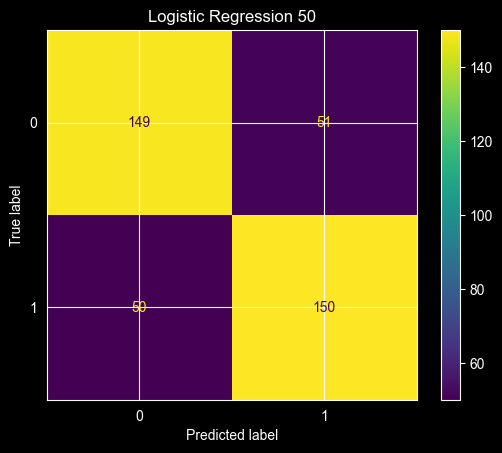


WORD2VEC: 100

Logistic Regression
Accuracy: 0.7475
[[149  51]
 [ 50 150]]

KNN
0.695
[[136  64]
 [ 58 142]]


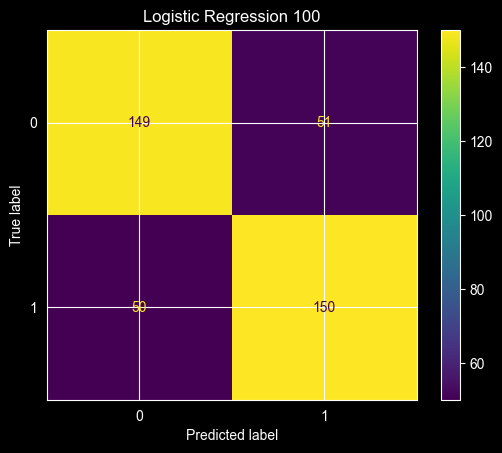


WORD2VEC: 200

Logistic Regression
Accuracy: 0.76
[[151  49]
 [ 47 153]]

KNN
0.6825
[[139  61]
 [ 66 134]]


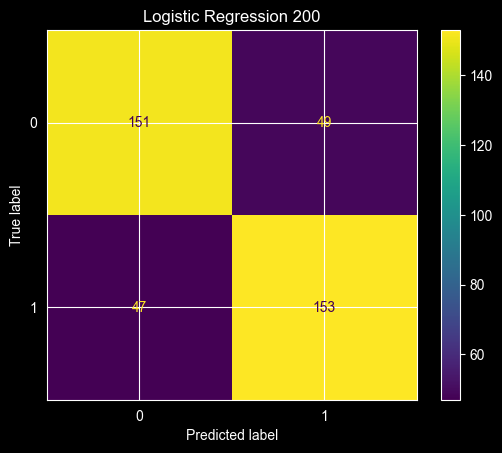


PART 2 : BBC + GLOVE
Documents: 2225

GLOVE 50
OOV Percentage: 0.21

Logistic Regression
0.9573033707865168
               precision    recall  f1-score   support

     business       0.94      0.94      0.94       102
entertainment       0.96      1.00      0.98        77
     politics       0.92      0.90      0.91        84
        sport       1.00      0.98      0.99       102
         tech       0.96      0.96      0.96        80

     accuracy                           0.96       445
    macro avg       0.96      0.96      0.96       445
 weighted avg       0.96      0.96      0.96       445


Linear SVM
0.9662921348314607
               precision    recall  f1-score   support

     business       0.96      0.95      0.96       102
entertainment       0.99      0.99      0.99        77
     politics       0.93      0.94      0.93        84
        sport       1.00      0.99      1.00       102
         tech       0.95      0.96      0.96        80

     accuracy                 

C:\Users\Almahdi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


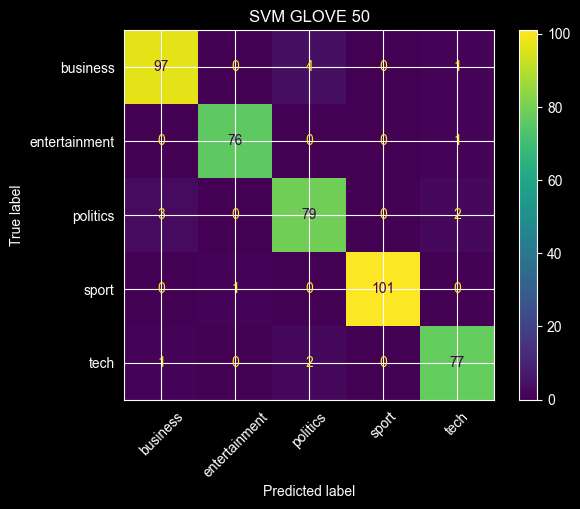


GLOVE 100
OOV Percentage: 0.21

Logistic Regression
0.9617977528089887
               precision    recall  f1-score   support

     business       0.97      0.94      0.96       102
entertainment       0.95      0.99      0.97        77
     politics       0.92      0.94      0.93        84
        sport       1.00      0.99      1.00       102
         tech       0.96      0.95      0.96        80

     accuracy                           0.96       445
    macro avg       0.96      0.96      0.96       445
 weighted avg       0.96      0.96      0.96       445


Linear SVM
0.9842696629213483
               precision    recall  f1-score   support

     business       0.99      0.97      0.98       102
entertainment       0.99      1.00      0.99        77
     politics       0.98      0.98      0.98        84
        sport       1.00      1.00      1.00       102
         tech       0.96      0.97      0.97        80

     accuracy                           0.98       445
    macro av

C:\Users\Almahdi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


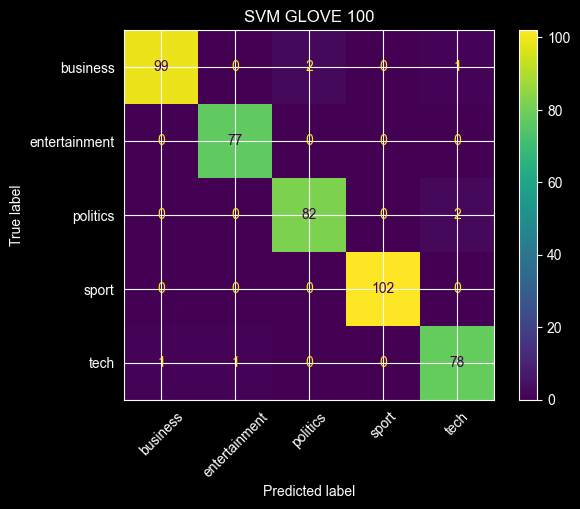


GLOVE 200
OOV Percentage: 0.21

Logistic Regression
0.9640449438202248
               precision    recall  f1-score   support

     business       0.97      0.95      0.96       102
entertainment       0.96      0.99      0.97        77
     politics       0.92      0.94      0.93        84
        sport       1.00      0.99      1.00       102
         tech       0.96      0.95      0.96        80

     accuracy                           0.96       445
    macro avg       0.96      0.96      0.96       445
 weighted avg       0.96      0.96      0.96       445


Linear SVM
0.9842696629213483
               precision    recall  f1-score   support

     business       0.99      0.97      0.98       102
entertainment       0.99      1.00      0.99        77
     politics       0.98      0.98      0.98        84
        sport       1.00      1.00      1.00       102
         tech       0.96      0.97      0.97        80

     accuracy                           0.98       445
    macro av

C:\Users\Almahdi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


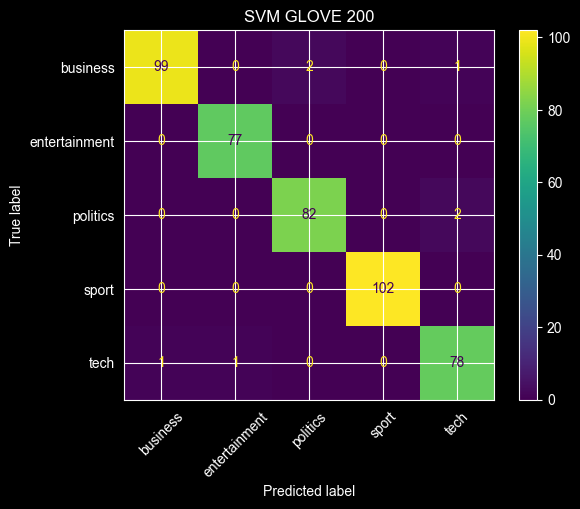


DONE.


In [5]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from nltk.corpus import movie_reviews
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import LabelEncoder

from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec


######################################################
# PATHS
######################################################

BBC_PATH = r"C:\Users\Almahdi\Desktop\NLP_MohammadAminKiani_4043644008\code\bbc"

GLOVE_PATH = r"C:\Users\Almahdi\Desktop\NLP_MohammadAminKiani_4043644008\code\glove"

RANDOM_STATE = 42

VECTOR_SIZES = [50,100,200]

TOKEN_PATTERN = re.compile(r"[a-z]+")


######################################################
# PREPROCESS
######################################################

def preprocess(text):

    return TOKEN_PATTERN.findall(text.lower())


######################################################
# DOCUMENT VECTOR
######################################################

# def document_vector(words, model):
#
#     vectors = []
#
#     for w in words:
#
#         if w in model:
#
#             vectors.append(model[w])
#
#     if len(vectors) == 0:
#
#         return np.zeros(model.vector_size)
#
#     return np.mean(vectors, axis=0)

def document_vector(words, model):

    vectors = []

    for w in words:

        if w in model.key_to_index:
            vectors.append(model[w])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)


######################################################
# PART 1
######################################################

print("\n==============================")
print("PART 1 : MOVIE REVIEWS")
print("==============================")

docs = []
labels = []

for fileid in movie_reviews.fileids():

    words = movie_reviews.words(fileid)

    text = " ".join(words)

    docs.append(preprocess(text))

    labels.append(movie_reviews.categories(fileid)[0])

y = np.array([1 if x=="pos" else 0 for x in labels])

X_train_docs, X_test_docs, y_train, y_test = train_test_split(
    docs,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

for dim in VECTOR_SIZES:

    print("\nWORD2VEC:",dim)

    w2v = Word2Vec(
        sentences=X_train_docs,
        vector_size=dim,
        window=5,
        min_count=2,
        workers=4,
        sg=1,
        epochs=10,
        seed=RANDOM_STATE
    )

    X_train = np.array([
        document_vector(doc,w2v.wv)
        for doc in X_train_docs
    ])

    X_test = np.array([
        document_vector(doc,w2v.wv)
        for doc in X_test_docs
    ])

    ##################################################
    # Logistic Regression
    ##################################################

    lr = LogisticRegression(max_iter=3000)

    lr.fit(X_train,y_train)

    pred_lr = lr.predict(X_test)

    print("\nLogistic Regression")

    print(
        "Accuracy:",
        accuracy_score(y_test,pred_lr)
    )

    print(
        confusion_matrix(y_test,pred_lr)
    )

    ##################################################
    # KNN
    ##################################################

    knn = KNeighborsClassifier(
        n_neighbors=3,
        metric="cosine"
    )

    knn.fit(X_train,y_train)

    pred_knn = knn.predict(X_test)

    print("\nKNN")

    print(
        accuracy_score(y_test,pred_knn)
    )

    print(
        confusion_matrix(y_test,pred_knn)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix(y_test,pred_lr)
    )

    disp.plot()

    plt.title(
        f"Logistic Regression {dim}"
    )

    plt.show()


######################################################
# BBC DATASET
######################################################

print("\n==============================")
print("PART 2 : BBC + GLOVE")
print("==============================")

texts = []
labels = []

bbc_root = Path(BBC_PATH)

for category in bbc_root.iterdir():

    if category.is_dir():

        for file in category.glob("*.txt"):

            text = file.read_text(
                encoding="latin1",
                errors="ignore"
            )

            texts.append(
                preprocess(text)
            )

            labels.append(category.name)

encoder = LabelEncoder()

y = encoder.fit_transform(labels)

X_train_docs, X_test_docs, y_train, y_test = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Documents:",len(texts))

######################################################
# GLOVE LOOP
######################################################

for dim in [50,100,200]:

    print("\n===================")
    print("GLOVE",dim)
    print("===================")

    glove_file = os.path.join(
        GLOVE_PATH,
        f"glove.6B.{dim}d.txt"
    )

    converted = os.path.join(
        GLOVE_PATH,
        f"glove.{dim}.txt"
    )

    if not os.path.exists(converted):

        glove2word2vec(
            glove_file,
            converted
        )

    model = KeyedVectors.load_word2vec_format(
        converted,
        binary=False
    )

    ##################################################
    # OOV
    ##################################################

    total = 0
    oov = 0

    for doc in texts:

        for word in doc:

            total += 1

            if word not in model:

                oov += 1

    print(
        "OOV Percentage:",
        round(100*oov/total,2)
    )

    ##################################################
    # DOCUMENT EMBEDDINGS
    ##################################################

    X_train = np.array([
        document_vector(doc,model)
        for doc in X_train_docs
    ])

    X_test = np.array([
        document_vector(doc,model)
        for doc in X_test_docs
    ])

    ##################################################
    # Logistic Regression
    ##################################################

    lr = LogisticRegression(
        max_iter=5000,
        multi_class="ovr"
    )

    lr.fit(X_train,y_train)

    pred_lr = lr.predict(X_test)

    print("\nLogistic Regression")

    print(
        accuracy_score(y_test,pred_lr)
    )

    print(
        classification_report(
            y_test,
            pred_lr,
            target_names=encoder.classes_
        )
    )

    ##################################################
    # SVM
    ##################################################

    svm = LinearSVC()

    svm.fit(X_train,y_train)

    pred_svm = svm.predict(X_test)

    print("\nLinear SVM")

    print(
        accuracy_score(y_test,pred_svm)
    )

    print(
        classification_report(
            y_test,
            pred_svm,
            target_names=encoder.classes_
        )
    )

    cm = confusion_matrix(
        y_test,
        pred_svm
    )

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=encoder.classes_
    )

    disp.plot(
        xticks_rotation=45
    )

    plt.title(
        f"SVM GLOVE {dim}"
    )

    plt.show()

print("\nDONE.")